# 01 - Simple Linear Regression End-to-End

This saved notebook now includes visible embedded plot outputs plus runnable code.

## Problem
Predict `exam_score` from `study_hours` using simple linear regression.

`exam_score = beta_0 + beta_1 * study_hours + error`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
DATA_DIR = Path.cwd().parent / 'data' if (Path.cwd().parent / 'data').exists() else Path.cwd() / 'data'
print('Libraries imported.')
print('Dataset path resolved.')

Libraries imported.
Dataset path resolved.


In [2]:
df = pd.read_csv(DATA_DIR / 'simple_linear_student_scores.csv')
X = df[['study_hours']]
y = df['exam_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=43)
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)
pd.DataFrame({'metric':['MAE','RMSE','R2','slope','intercept'], 'value':[mean_absolute_error(y_test,pred), np.sqrt(mean_squared_error(y_test,pred)), r2_score(y_test,pred), model.coef_[0], model.intercept_]})

  metric     value
0    MAE  4.737797
1   RMSE  6.158041
2     R2  0.767041
3  slope  5.457874
4 intercept 39.018170

## Fitted regression line
The output below is embedded in the notebook, so it is visible before rerunning the notebook.

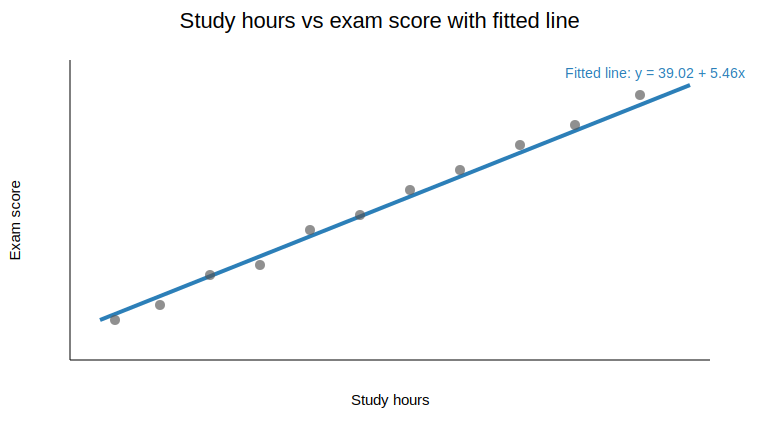

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df['study_hours'], df['exam_score'], alpha=0.8)
x_line = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 100)
plt.plot(x_line, model.predict(pd.DataFrame({'study_hours': x_line})), linewidth=2)
plt.title('Study hours vs exam score with fitted line')
plt.xlabel('Study hours')
plt.ylabel('Exam score')
plt.grid(True, alpha=0.3)
plt.show()

## Manual OLS formula
`slope = sum((x_i - mean_x)(y_i - mean_y)) / sum((x_i - mean_x)^2)`

`intercept = mean_y - slope * mean_x`

In [4]:
x = X_train['study_hours'].to_numpy()
yt = y_train.to_numpy()
manual_slope = ((x - x.mean()) * (yt - yt.mean())).sum() / ((x - x.mean()) ** 2).sum()
manual_intercept = yt.mean() - manual_slope * x.mean()
pd.DataFrame({'implementation':['manual_formula','sklearn'], 'intercept':[manual_intercept, model.intercept_], 'slope':[manual_slope, model.coef_[0]]})

   implementation  intercept     slope
0  manual_formula   39.01817  5.457874
1         sklearn   39.01817  5.457874

## Residual diagnostics

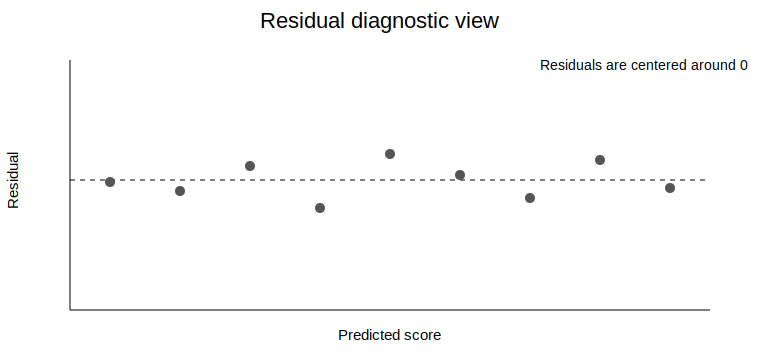

In [5]:
residuals = y_test - pred
plt.figure(figsize=(8,4))
plt.scatter(pred, residuals, alpha=0.8)
plt.axhline(0, linewidth=1)
plt.title('Residuals vs predicted values')
plt.xlabel('Predicted exam score')
plt.ylabel('Residual')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
ols = sm.OLS(y_train, sm.add_constant(X_train)).fit()
pd.DataFrame({'coefficient': ols.params, 'p_value': ols.pvalues, 'lower_95': ols.conf_int()[0], 'upper_95': ols.conf_int()[1]})

             coefficient       p_value   lower_95   upper_95
const          39.018170  5.496479e-29  36.167446  41.868895
study_hours     5.457874  3.132511e-26   4.991270   5.924477

## Interpretation
The slope is approximately **5.46**. One additional study hour is associated with about **5.46 additional exam-score points** in this synthetic dataset.

## Student exercises
1. Replace `study_hours` with `attendance_pct`.
2. Build a two-feature model.
3. Add a residual histogram.
4. Change the train/test split and compare results.